
# Experiment 15: RNN Model to Predict Miles Travelled by Vehicles

## Objective
To create a Recurrent Neural Network (RNN) model and use it to predict miles travelled by vehicles from time-series data.



In [1]:

# Install only if needed:
# !pip install numpy pandas matplotlib scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

np.random.seed(42)
tf.random.set_seed(42)


## 1. Create / load dataset

In [2]:

# Synthetic vehicle miles travelled dataset
# We simulate 500 days of travel with trend + seasonality + noise

days = 500
date_index = pd.date_range(start="2023-01-01", periods=days, freq="D")

trend = np.linspace(50, 120, days)                         # slow increase in miles over time
seasonality = 12 * np.sin(np.arange(days) * 2 * np.pi / 30)  # monthly-like pattern
weekly_pattern = 5 * np.sin(np.arange(days) * 2 * np.pi / 7) # weekly pattern
noise = np.random.normal(0, 4, days)

miles = trend + seasonality + weekly_pattern + noise
miles = np.maximum(miles, 5)  # keep all values positive

df = pd.DataFrame({
    "Date": date_index,
    "Miles_Travelled": miles
})

df.head()


,Date,Miles_Travelled
0,2023-01-01,51.986857
1,2023-01-02,55.991321
2,2023-01-03,62.626795
3,2023-01-04,65.735803
4,2023-01-05,56.372828


In [3]:

# Uncomment and use this instead if you have your own CSV file
# Expected columns: Date, Miles_Travelled

# df = pd.read_csv("vehicle_miles.csv")
# df["Date"] = pd.to_datetime(df["Date"])
# df = df.sort_values("Date").reset_index(drop=True)
# df.head()


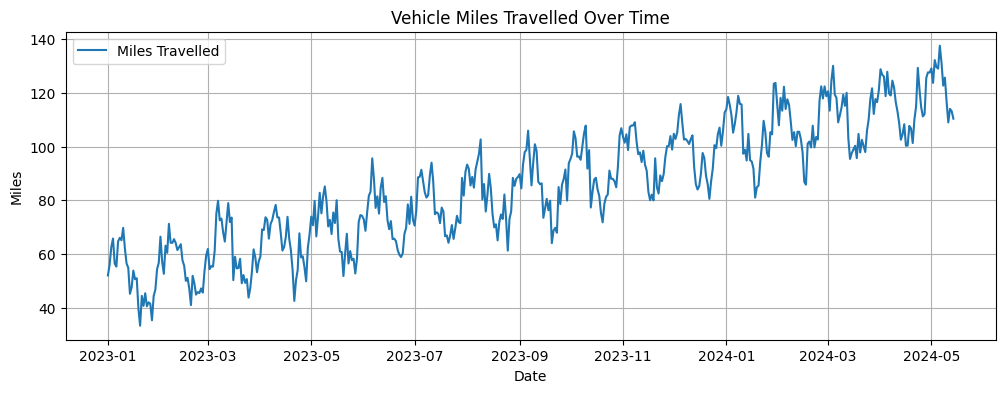

In [4]:

plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["Miles_Travelled"], label="Miles Travelled")
plt.title("Vehicle Miles Travelled Over Time")
plt.xlabel("Date")
plt.ylabel("Miles")
plt.legend()
plt.grid(True)
plt.show()


## 2. Preprocess data

In [5]:

data = df["Miles_Travelled"].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print("Original shape:", data.shape)
print("Scaled shape:", scaled_data.shape)


Original shape: (500, 1)
Scaled shape: (500, 1)


## 3. Convert time series into supervised learning sequences

In [6]:

def create_sequences(dataset, time_steps=20):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:i + time_steps, 0])
        y.append(dataset[i + time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 20
X, y = create_sequences(scaled_data, time_steps)

# reshape for RNN: [samples, time_steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (480, 20, 1)
y shape: (480,)


## 4. Train-test split

In [7]:

split_index = int(0.8 * len(X))

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 384
Testing samples: 96


## 5. Build the RNN model

In [8]:

model = Sequential([
    SimpleRNN(50, activation="tanh", return_sequences=True, input_shape=(time_steps, 1)),
    Dropout(0.2),
    SimpleRNN(30, activation="tanh"),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 20, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 30)             │         2,430 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,061 (19.77 KB)

 Trainable params: 5,061 (19.77 KB)

 Non-trainable params: 0 (0.00 B)

### Accessing Model Weights and Biases

In a neural network, **weights** determine the strength of the connection between neurons, and **biases** are added to the output of each neuron, allowing the activation function to be shifted. These parameters are learned during the training process. We can inspect them to understand the model's internal state.

In [9]:
print("\n--- Model Weights and Biases ---")
for i, layer in enumerate(model.layers):
    if len(layer.get_weights()) > 0:
        print(f"\nLayer {i}: {layer.name}")
        weights = layer.get_weights()

        # Weights usually come first, then biases
        if len(weights) > 0:
            print(f"  Weights shape: {weights[0].shape}")
            # Optionally, print a small part of the weights
            # print(f"  Weights (first 5 values):\n{weights[0].flatten()[:5]}")
        if len(weights) > 1:
            print(f"  Bias shape: {weights[1].shape}")
            # Optionally, print a small part of the biases
            # print(f"  Bias (first 5 values): {weights[1].flatten()[:5]}")
        if len(weights) > 2: # For RNNs, there can be recurrent weights
            print(f"  Recurrent Weights shape: {weights[2].shape}")



--- Model Weights and Biases ---

Layer 0: simple_rnn
  Weights shape: (1, 50)
  Bias shape: (50, 50)
  Recurrent Weights shape: (50,)

Layer 2: simple_rnn_1
  Weights shape: (50, 30)
  Bias shape: (30, 30)
  Recurrent Weights shape: (30,)

Layer 4: dense
  Weights shape: (30, 1)
  Bias shape: (1,)


## 6. Train the model

In [10]:

history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.2111 - val_loss: 0.0084
Epoch 2/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0819 - val_loss: 0.0212
Epoch 3/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0535 - val_loss: 0.0068
Epoch 4/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0442 - val_loss: 0.0107
Epoch 5/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0317 - val_loss: 0.0125
Epoch 6/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0337 - val_loss: 0.0047
Epoch 7/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0275 - val_loss: 0.0037
Epoch 8/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0237 - val_loss: 0.0037
Epoch 9/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0201 - val_loss: 0.0050
Epoch 10/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0199 - val_loss: 0.0058
Epoch 11/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0166 - val_loss: 0.0034
Epoch 12/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

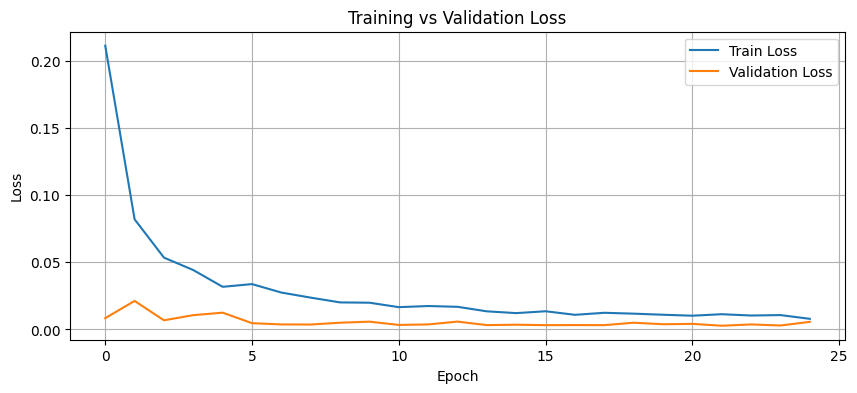

In [11]:

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## 7. Predict miles travelled

In [12]:

y_pred = model.predict(X_test)

# Convert scaled values back to original scale
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred)

results = pd.DataFrame({
    "Actual_Miles": y_test_actual.flatten(),
    "Predicted_Miles": y_pred_actual.flatten()
})

results.head(10)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 


,Actual_Miles,Predicted_Miles
0,102.493386,102.302017
1,105.395870,100.097473
2,100.188486,99.517822
3,105.552988,100.650818
4,105.536868,99.855827
5,102.684186,96.419037
6,97.799766,94.101181
7,86.869424,93.804924
8,85.815714,87.486259
9,101.112316,89.041931


## 8. Evaluate the model

In [13]:

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")


MAE  : 6.424
RMSE : 7.855
R²   : 0.494


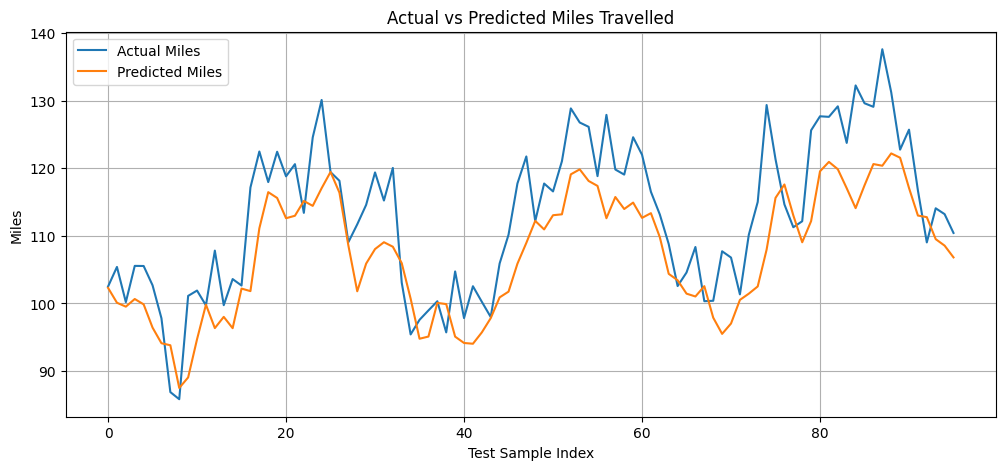

In [14]:

plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label="Actual Miles")
plt.plot(y_pred_actual, label="Predicted Miles")
plt.title("Actual vs Predicted Miles Travelled")
plt.xlabel("Test Sample Index")
plt.ylabel("Miles")
plt.legend()
plt.grid(True)
plt.show()


## 9. Predict next day's miles

In [15]:

last_sequence = scaled_data[-time_steps:].reshape(1, time_steps, 1)
next_day_scaled = model.predict(last_sequence)
next_day_miles = scaler.inverse_transform(next_day_scaled)

print("Predicted miles for next day:", round(float(next_day_miles[0][0]), 2))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
Predicted miles for next day: 104.25
